In [1]:
import sys, pickle
sys.path.append('../src')
import numpy as np
from scipy.linalg import svd
from scipy.stats import permutation_test, wilcoxon
from tqdm import tqdm
import matplotlib.pyplot as plt
from utils import *
from helper_funcs import *
from visualization import plot_mean_std
rng = np.random.default_rng()

In [2]:
ALL_REC_PLASTICITYS = ('EE', 'EIIE')
ALL_MODES = ('shuffleAll', 'shuffleE', 'noise', 'zero', 'swap')
REC_PLASTICITY = ALL_REC_PLASTICITYS[1]
MODE = ALL_MODES[0]

In [3]:
XS_PERT = np.linspace(0, 1, num=6) # off manifold (perturbation)
XS_SCALE = np.linspace(0, 1, num=6) # on manifold (song scaling)

In [4]:
svds = []
rate_onm_train, rate_offm_train = [], []
rate_onm_modepert, rate_offm_modepert = [], []
for i in range(10):
    with open(f'../results/{REC_PLASTICITY}_J_disr_exp_meta_{i}.pkl', 'rb') as f:
        res = pickle.load(f)
        # syl is directly derived from the input data, so all are the same
        syl = res['syl']
        svds.append(res['svds'])
    
    NE = syl.shape[1]

    # Test 1: response to various inputs during training
    with open(f'../results/{REC_PLASTICITY}_response_during_training_{i}.pkl', 'rb') as f:
        res = pickle.load(f)
    
    rate_onm_train += [res['on_manifold']]
    rate_offm_train += [res['off_manifold']]

    if i == 0:
        train_steps = res['on_manifold'].shape[0]

    # Test 2: post-training mode perturbation response to various inputs
    with open(f'../results/{REC_PLASTICITY}_J_disr_exp_{MODE}_{i}.pkl', 'rb') as f:
        res = pickle.load(f)
    
    rate_onm_modepert += res['on_manifold']
    rate_offm_modepert += res['off_manifold']
    
    if i == 0:
        print('Order of mode perturbation:', res['order'])
        n_case = len(res['order'])
        n_shuffle = len(res['on_manifold'])

# (trials, training step, pert values, NE)
rate_onm_train, rate_offm_train = np.stack(rate_onm_train), np.stack(rate_offm_train)

# (trials, cases, pert values, NE)
rate_onm_modepert, rate_offm_modepert = np.stack(rate_onm_modepert), np.stack(rate_offm_modepert)

Order of mode perturbation: ['original', 'memory', 'landscape', 'rand']


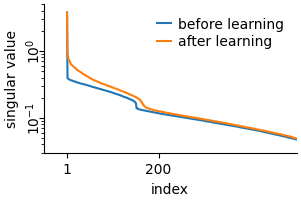

In [5]:
fig, ax = plt.subplots(1, figsize=(3, 2))
i = np.arange(1, len(svds[0][0][1])+1)
ax.plot(i, svds[0][0][1], label='before learning')
ax.plot(i, svds[0][-1][1], label='after learning')
ax.legend()
ax.set(yscale='log', ylim=[3e-2, 5], xlim=[-50, 500], xticks=[1, 200],
       ylabel='singular value', xlabel='index')
ax.set_yticks([1e-1, 1], labels=['$10^{-1}$', '$10^0$'], 
              ha='center', va='center', rotation=90)
fig.savefig(f'../svg/EIrec_analysis/{MODE}_log_singular_value.svg')

[2 3 5 7] [2 3 4 5 6 7]


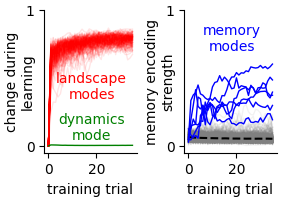

In [6]:
change, i_outlier, i_nonout = characterize_change(svds[1], first_n=150)
mem_enc, i_memory, i_nonmem = characterize_memory(svds[1], syl, 'left')
i_landscape = [i for i in i_nonmem if i != 0 and i < 150]

print(i_outlier + 1, i_memory + 1)

fig, ax = plt.subplots(1, 2, figsize=(2.8,2))

ax[0].plot(change[:,i_landscape], c='r', alpha=0.1, lw=1, zorder=-1)
ax[0].text(change.shape[0]//2, 0.35, 'landscape\nmodes', ha='center', c='r')
# ax[0].plot(change[:,i_memory], c='b', alpha=0.6, lw=1, zorder=-1)
# ax[0].plot(change[:,150:], c='purple', alpha=0.1, lw=1, zorder=-1)
# ax[0].plot(change, c='grey', alpha=0.1, lw=1, zorder=-1)
# ax[0].plot(change[:,1:].mean(axis=1), c='k', ls='--', zorder=1)
ax[0].plot(change[:,0], c='g', lw=1, zorder=2)
ax[0].text(change.shape[0]//2, 0.05, 'dynamics\nmode', ha='center', c='g')
ax[0].set(yticks=[0, 1], ylim=[-0.05, 1])
ax[0].set_ylabel('change during\nlearning', va='center')
ax[0].set_xlabel('training trial', va='top')
ax[1].set_rasterization_zorder(0)

ax[1].plot(mem_enc[:,i_nonmem], c='grey', alpha=0.1, lw=1, zorder=-1)
ax[1].plot(mem_enc[:,i_nonmem].mean(axis=1), c='k', ls='--', zorder=1)
ax[1].plot(mem_enc[:,i_memory], c='b', lw=1, alpha=1, zorder=1)
ax[1].text(change.shape[0]//2, 0.7, 'memory\nmodes', ha='center', c='b')
ax[1].set(ylim=[-0.05, 1], yticks=[0, 1])
ax[1].set_ylabel('memory encoding\nstrength', va='center')
ax[1].set_xlabel('training trial', va='top')
ax[1].set_rasterization_zorder(0)

fig.savefig(f'../svg/EIrec_analysis/{MODE}_mode_learning_curves_E2I2E.svg')

In [7]:
def get_timeconst(x):
    xmin, xmax = x.min(axis=0), x.max(axis=0)
    x = (x - xmin) / (xmax - xmin)
    return np.where(x > 1 - 5**(-1))[0][0]

tc_landscape, tc_memory = [], []
for i in range(len(svds)):
    change = characterize_change(svds[i])[0]
    mem_enc, i_memory, i_nonmem = characterize_memory(svds[i], syl, 'left')
    i_landscape = i_nonmem[1:10] 
    tc_landscape.append(get_timeconst(change[:,i_landscape].mean(axis=1)))
    tc_memory.append(get_timeconst(mem_enc[:,i_memory].mean(axis=1)))

0.0009765625


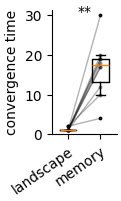

In [8]:
fig, ax = plt.subplots(1, figsize=(1.2,2))
for x, y in zip(tc_landscape, tc_memory):
    ax.plot([1, 2], [x, y], '-o', c='k', alpha=0.3, ms=2, lw=1)
ax.boxplot([tc_landscape, tc_memory], widths=[0.5, 0.5])
pval = wilcoxon(tc_landscape, tc_memory, alternative='less').pvalue
print(pval)
if pval < 0.05:
    ax.text(1.5, np.max(tc_memory), '**' if pval < 0.01 else '*', ha='center')
else:
    ax.text(1.5, np.max(tc_memory), 'ns', ha='center', va='bottom')
ax.set(ylim=[0, ax.get_ylim()[1]], ylabel='convergence time')
ax.set_xticklabels(['landscape', 'memory'], rotation=35, ha='right', rotation_mode='anchor')
fig.savefig(f'../svg/EIrec_analysis/{MODE}_mode_time_constants.svg')

## Test 1

[Text(0.5, 0, 'training time'), Text(0, 0.5, 'midpoint slope')]

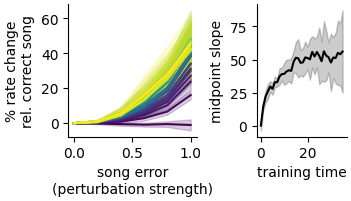

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(3.5,2), width_ratios=[1,0.7])

m = rate_offm_train.mean(axis=-1) # (trials, training step, pert values)
m = (m / m[...,0,None] - 1) * 100
g = np.gradient(m, XS_PERT, axis=-1)[...,3] # (trials, training step)

cmap = plt.get_cmap('viridis')
for i in range(train_steps):
    plot_mean_std(ax[0], m[:,i].mean(axis=0), m[:,i].std(axis=0), 
                  a_fill=0.2, c=cmap(i/(train_steps-1)), xs=XS_SCALE)
plot_mean_std(ax[1], g.mean(axis=0), g.std(axis=0), 
              a_fill=0.2, c='k', xs=np.arange(train_steps))

ax[0].set(xlabel='song error\n(perturbation strength)', 
          ylabel='% rate change\nrel. correct song')
ax[1].set(xlabel='training time', ylabel='midpoint slope')

[Text(0.5, 0, 'training time'), Text(0, 0.5, 'minimum location')]

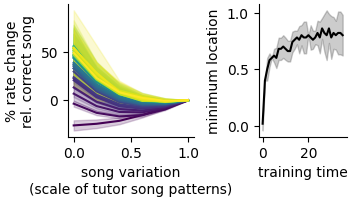

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(3.5,2), width_ratios=[1,0.7])

m = rate_onm_train.mean(axis=-1) # (trials, training step, pert values)
m = (m / m[...,-1,None] - 1) * 100
min_locs = XS_SCALE[np.argmin(m, axis=-1)] # (trials, training step)

cmap = plt.get_cmap('viridis')
for i in range(train_steps):
    plot_mean_std(ax[0], m[:,i].mean(axis=0), m[:,i].std(axis=0), 
                  a_fill=0.2, c=cmap(i/(train_steps-1)), xs=XS_SCALE)
plot_mean_std(ax[1], min_locs.mean(axis=0), min_locs.std(axis=0), 
              a_fill=0.2, c='k', xs=np.arange(train_steps))
    
ax[0].set(xlabel='song variation\n(scale of tutor song patterns)', 
          ylabel='% rate change\nrel. correct song')
ax[1].set(xlabel='training time', ylabel='minimum location')

## Test 2

In [11]:
case_names = ['original', 'without memory modes', 'without top 15 landscape modes', 
              'without top 15 other modes']
case_colors = ['k', 'b', 'r', 'purple']

6.921610095552685e-07
4.952385912913811e-08
7.075598214146847e-15
0.14388106900610403


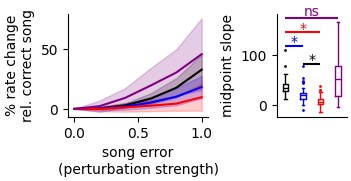

In [12]:
from scipy.stats import ranksums
fig, ax = plt.subplots(1, 2, figsize=(3.5,1.8), width_ratios=[1,0.5])

m = rate_offm_modepert.mean(axis=-1)
m = (m / m[...,0,None] - 1) * 100
g = np.gradient(m, XS_PERT, axis=-1)[...,3]

for i, c in enumerate(case_colors):
    plot_mean_std(ax[0], m[:,i].mean(axis=0), m[:,i].std(axis=0), 
                  a_fill=0.2, c=c, xs=XS_PERT)
    ax[1].boxplot(g[:,i], positions=[i], 
                  widths=0.3, flierprops=dict(ms=2, mec=c), 
                  boxprops=dict(color=c), capprops=dict(color=c),
                  whiskerprops=dict(color=c), medianprops=dict(color=c))
    
pval, y = ranksums(g[:,1], g[:,2]).pvalue, g.max() * 0.5
print(pval)
ax[1].hlines(y, 1, 2, color='k')
if pval < 0.01:
    ax[1].text(1.5, y, '*', ha='center', c='k')
else:
    ax[1].text(1.5, y, 'ns', ha='center', va='bottom', c='k')
    
for i, c in enumerate(case_colors[1:], 1):
    pval = ranksums(g[:,0], g[:,i]).pvalue
    print(pval)
    y = g.max() * 0.5 * (1.1 + i / 3)
    ax[1].hlines(y, 0, i, color=c)
    if pval < 0.01:
        ax[1].text(i/2, y, '*', ha='center', c=c)
    else:
        ax[1].text(i/2, y, 'ns', ha='center', va='bottom', c=c)
    
ax[0].set(xlabel='song error\n(perturbation strength)', 
          ylabel='% rate change\nrel. correct song')
ax[1].set(xticks=[], ylabel='midpoint slope')
fig.savefig(f'../svg/EIrec_analysis/{MODE}_off_manifold_perturb.svg')

2.8808497011912092e-11
0.059367795596803725
3.2875156934683045e-16


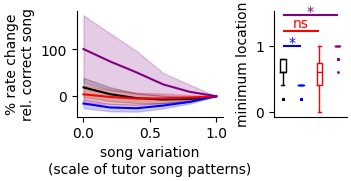

In [13]:
from scipy.stats import ranksums
fig, ax = plt.subplots(1, 2, figsize=(3.5,1.8), width_ratios=[1,0.5])

m = rate_onm_modepert.mean(axis=-1)
m = (m / m[...,-1,None] - 1) * 100
min_locs = XS_SCALE[np.argmin(m, axis=-1)]

for i, c in enumerate(case_colors):
    plot_mean_std(ax[0], m[:,i].mean(axis=0), m[:,i].std(axis=0), 
                  a_fill=0.2, c=c, xs=XS_SCALE)
    ax[1].boxplot(min_locs[:,i], positions=[i],
                  widths=0.3, flierprops=dict(ms=2, mec=c), 
                  boxprops=dict(color=c), capprops=dict(color=c),
                  whiskerprops=dict(color=c), medianprops=dict(color=c))

for i, c in enumerate(case_colors[1:], 1):
    pval = ranksums(min_locs[:,0], min_locs[:,i]).pvalue
    print(pval)
    y = min_locs.max() * 0.7 * (1.1 + i / 3)
    ax[1].hlines(y, 0, i, color=c)
    if pval < 0.01:
        ax[1].text(i/2, y, '*', ha='center', c=c)
    else:
        ax[1].text(i/2, y, 'ns', ha='center', va='bottom', c=c)

ax[0].set(xlabel='song variation\n(scale of tutor song patterns)', 
          ylabel='% rate change\nrel. correct song')
ax[1].set(xticks=[], ylabel='minimum location')
fig.savefig(f'../svg/EIrec_analysis/{MODE}_on_manifold_perturb.svg')

[[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [2.22895485e-15 2.35609766e-15 2.94007206e-15 2.10857433e-15
  4.09255867e-15 5.09737038e-15]
 [6.85664145e-18 6.85664145e-18 6.85664145e-18 6.85664145e-18
  7.28181386e-18 7.28181386e-18]
 [4.12934290e-16 5.18284730e-16 2.46969576e-16 3.22715547e-17
  1.10806655e-17 6.85664145e-18]]


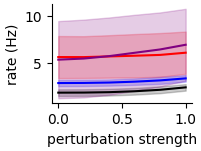

In [14]:
fig, ax = plt.subplots(1, figsize=(2,1.5))

m = rate_offm_modepert.mean(axis=-1)

for i, c in enumerate(case_colors):
    plot_mean_std(ax, m[:,i].mean(axis=0), m[:,i].std(axis=0), 
                  a_fill=0.2, c=c, xs=XS_PERT)
pvals = np.zeros((len(case_names), m.shape[-1]))
for i in range(len(case_names)):
    for j in range(m.shape[-1]):
        pvals[i,j] = ranksums(m[:,0,j], m[:,i,j]).pvalue
print(pvals)
ax.set(xlabel='perturbation strength', ylabel='rate (Hz)')
fig.savefig(f'../svg/EIrec_analysis/{MODE}_off_manifold_perturb_unnormalized.svg')

[[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
  1.00000000e+00 1.00000000e+00]
 [2.80803209e-07 2.64701039e-08 8.79632424e-15 1.31086609e-16
  1.31086609e-16 2.22895485e-15]
 [6.85664145e-18 6.85664145e-18 6.85664145e-18 6.85664145e-18
  6.85664145e-18 6.85664145e-18]
 [6.85664145e-18 6.85664145e-18 6.85664145e-18 6.85664145e-18
  6.85664145e-18 4.12934290e-16]]


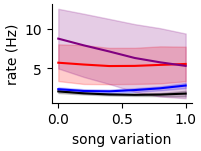

In [15]:
fig, ax = plt.subplots(1, figsize=(2,1.5))

m = rate_onm_modepert.mean(axis=-1)

for i, c in enumerate(case_colors):
    plot_mean_std(ax, m[:,i].mean(axis=0), m[:,i].std(axis=0), 
                  a_fill=0.2, c=c, xs=XS_PERT)
pvals = np.zeros((len(case_names), m.shape[-1]))
for i in range(len(case_names)):
    for j in range(m.shape[-1]):
        pvals[i,j] = ranksums(m[:,0,j], m[:,i,j]).pvalue
print(pvals)
ax.set(xlabel='song variation', ylabel='rate (Hz)')
fig.savefig(f'../svg/EIrec_analysis/{MODE}_on_manifold_perturb_unnormalized.svg')

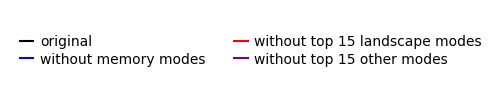

In [16]:
fig, ax = plt.subplots(1, figsize=(5,1))
for n, c in zip(case_names, case_colors):
    ax.plot(0, 0, c=c, label=n)
ax.set_axis_off()
ax.legend(loc='center', ncols=2, columnspacing=2)
fig.savefig(f'../svg/EIrec_analysis/dummy_label_EIrec_analysis.svg')

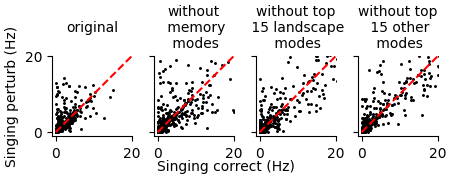

In [17]:
fig, ax = plt.subplots(1, n_case, sharex='all', sharey='all', figsize=(4.5, 2))
l = rng.integers(0, rate_onm_modepert.shape[0])
i_ctrl = 0 # index of singing correct
i_pert = -1 # index of singing perturb
for i, k in enumerate(case_names):
    z_ctrl = rate_offm_modepert[l,i,i_ctrl]
    z_pert = rate_offm_modepert[l,i,i_pert]
    ax[i].scatter(z_ctrl, z_pert, c='k', s=5, zorder=-1)
    ax[i].plot([0,50], [0,50], c='r', ls='--')
    k = k.split(' ')
    k[len(k)//4] = k[len(k)//4] + '\n'
    if len(k) > 1:
        k[-2] = k[-2] + '\n'
    k = ' '.join(k)
    ax[i].set(aspect=1, title=k, xlim=[-1,20], ylim=[-1,20])
    ax[i].set_rasterization_zorder(0)
ax[0].set(ylabel='Singing perturb (Hz)', xlabel='\n')
fig.text(0.5, 0.15, 'Singing correct (Hz)', ha='center', va='center')
fig.savefig(f'../svg/EIrec_analysis/{MODE}_joint_dist_J_disrupt_pert.svg')

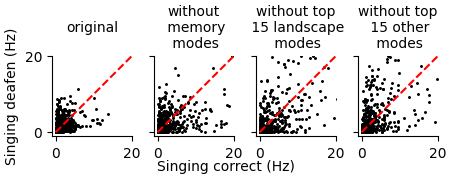

In [18]:
fig, ax = plt.subplots(1, n_case, sharex='all', sharey='all', figsize=(4.5, 2))
l = rng.integers(0, rate_onm_modepert.shape[0])
i_ctrl = -1 # index of singing correct
i_pert = 0 # index of singing perturb
for i, k in enumerate(case_names):
    z_ctrl = rate_onm_modepert[l,i,i_ctrl]
    z_pert = rate_onm_modepert[l,i,i_pert]
    ax[i].scatter(z_ctrl, z_pert, c='k', s=5, zorder=-1)
    ax[i].plot([0,50], [0,50], c='r', ls='--')
    k = k.split(' ')
    k[len(k)//4] = k[len(k)//4] + '\n'
    if len(k) > 1:
        k[-2] = k[-2] + '\n'
    k = ' '.join(k)
    ax[i].set(aspect=1, title=k, xlim=[-1,20], ylim=[-1,20])
    ax[i].set_rasterization_zorder(0)
ax[0].set(ylabel='Singing deafen (Hz)', xlabel='\n')
fig.text(0.5, 0.15, 'Singing correct (Hz)', ha='center', va='center')
fig.savefig(f'../svg/EIrec_analysis/{MODE}_joint_dist_J_disrupt_deafen.svg')

## Manipulating Dynamic Mode

In [19]:
with np.errstate(over='ignore', divide='ignore', invalid='ignore'):
    J0 = svds[-1][-1][0] @ np.diag(svds[-1][-1][1]) @ svds[-1][-1][2]
    J1 = svds[-1][-1][0][:,1:] @ np.diag(svds[-1][-1][1][1:]) @ svds[-1][-1][2][1:,:]
    # J1 += svds[-1][-1][0][:,-1] @ svds[-1][-1][2][-1,:] * svds[-1][-1][1][-1]
    J0[np.abs(J0)<1e-5] = 0
    J1[np.abs(J1)<1e-5] = 0

In [20]:
from models import *
from train_funcs import *

NE, NI, N_HVC = 600, 150, 15
PEAK_RATE, KERNEL_WIDTH = 150, 20
tauE, tauI, dt = 30, 10, 1
rEmax, rImax, thE, thI, slope = 100, 100, 0, 0, 2

### Read and map auditory inputs
fname = '../realistic_auditory_processing/learned_song_responses.npz'
aud_real, mapping = read_realistic_input(fname, NE, mean=0, scale=2, 
                                         mapping='neighbor', mapping_args=None)

### Time window of perturbation
PERT_T0 = int(np.round(aud_real['pert_t0'].min(), -1))
PERT_T1 = int(np.round(aud_real['pert_t1'].max(), -1)) + 100

### Constants related to time
T_post = 200 # Silence after song
T_song = aud_real['ctrl'].shape[2]
T_rend = T_song + T_post # Each rendition
N_rend = 35 # Number of renditions
T_burn = 500 # Burning
T = T_burn + N_rend * T_rend # Total
T_test = T_burn + T_rend

### Generate auditory inputs and HVC firing for training
aud, _ = generate_realistic_aud(aud_real['ctrl'], N_rend, T_burn, T_post)
_ = np.arange(N_rend)
# (N_HVC, N_rend)
burst_ts = np.linspace(_*T_rend+T_burn, _*T_rend+T_burn+T_song, num=N_HVC, endpoint=False)

_ = np.zeros((N_HVC, N_rend))
rH = generate_HVC(T, burst_ts, PEAK_RATE+_, KERNEL_WIDTH+_)

hE0 = rng.normal(loc=-10, scale=0.5, size=NE)
hI0 = rng.normal(loc=-1, scale=0.5, size=NI)

rs = []
for j in (J0, J1):
    with np.errstate(over='ignore', divide='ignore', invalid='ignore'):
        net = EINet(NE, NI, N_HVC, 1/N_HVC, (rEmax, thE, slope), 
                    (rImax, thI, slope), tauE, tauI, 
                    JEE=j[:NE,:NE], JEI=-j[:NE,NE:], 
                    JIE=j[NE:,:NE], JII=-j[NE:,NE:], 
                    w0_std=0, cW=0.05)
        rE, rI = net.sim(hE0, hI0, rH[:T_test], aud[:T_test], [], T_test, dt, 0.1, 
                         no_progress_bar=True)[:2]
    rs.append(np.concat((rE, rI), 1))

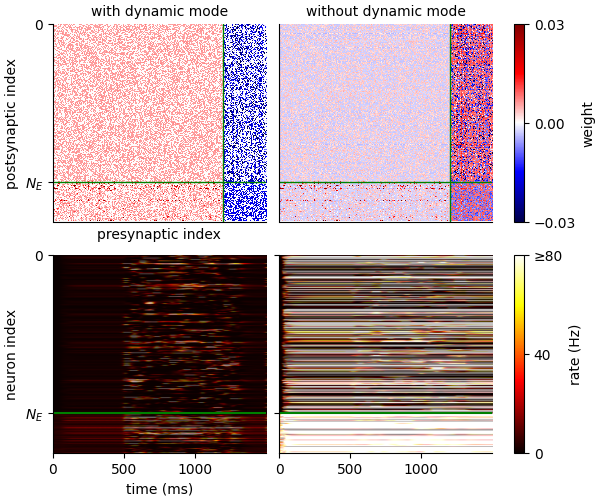

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(6,5))
for i, j in enumerate((J0, J1)):
    im = ax[0,i].imshow(j, cmap='seismic', vmin=-0.03, vmax=0.03, interpolation='none')
    ax[0,i].axhline(NE, c='g', lw=1)
    ax[0,i].axvline(NE, c='g', lw=1)
    ax[0,i].set(xticks=[], yticks=[], title=f'with{'' if i==0 else 'out'} dynamic mode')
ax[0,0].set(xlabel='presynaptic index', ylabel='postsynaptic index', 
            yticks=[0, NE], yticklabels=[0, '$N_E$'])
fig.colorbar(im, ax=ax[0], ticks=[-0.03, 0, 0.03], label='weight')
for i, r in enumerate(rs):
    im = ax[1,i].imshow(r.T, cmap='hot', vmin=0, vmax=80)
    ax[1,i].axhline(NE, c='g')
ax[1,0].set(xlabel='time (ms)', ylabel='neuron index', 
            yticks=[0, NE], yticklabels=[0, '$N_E$'])
ax[1,1].set(yticks=[0, NE], yticklabels=['', ''])
c = fig.colorbar(im, ax=ax[1], ticks=[0, 40, 80], label='rate (Hz)')
c.set_ticklabels([0, 40, '≥80'])
fig.savefig('../svg/supplementary/disrupt_dynamic_mode.svg')